Logistic Regression model trained successfully!
Predictions completed successfully!
First 10 predictions:
[1 0 0 0 1 1 1 0 1 0]


,Actual,Predicted
0,0,1
1,0,0
2,0,0
3,0,0
4,0,1
5,0,1
6,1,1
7,0,0
8,1,1
9,0,0


Confusion Matrix:
[[22  8]
 [ 5 25]]
Accuracy: 0.7833333333333333
Precision: 0.7575757575757576
Recall: 0.8333333333333334
F1-Score: 0.7936507936507938


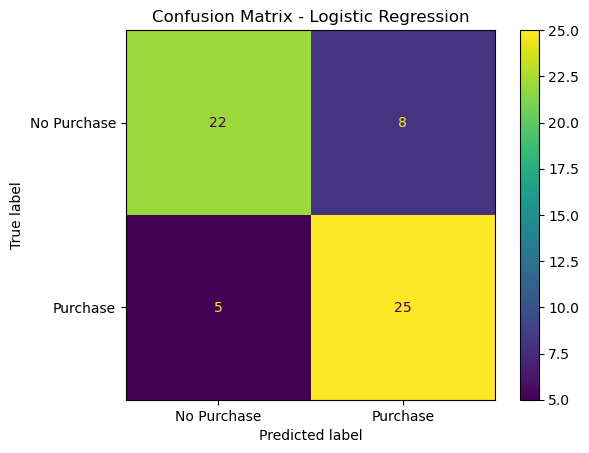

In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report 
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score, 
    ConfusionMatrixDisplay 
)
import matplotlib.pyplot as plt 

# 1. Load data
df = pd.read_csv("marketing_campaign_response_dataset (1).csv", skiprows=1)
df.columns = df.columns.str.strip()

# 2. Basic data preparation
df = df.drop_duplicates()
text_columns = ["Gender", "City", "Customer_Segment", "Email_Opened", "Discount_Offered", "Campaign_Channel", "Responded"]
for col in text_columns:
    df[col] = df[col].astype(str).str.strip().str.title()

# 3. Define features and target
feature_columns = ["Age", "Gender", "City", "Income",
"Customer_Segment", "Website_Visits", "Email_Opened",
"Ad_Clicks", "Previous_Purchases", "Discount_Offered",
"Campaign_Channel", "Customer_Satisfaction",
"Last_Month_Spending"
]
X = df[feature_columns]
y = df["Responded"].map({"No": 0, "Yes": 1})

# 4. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
X, y,
test_size=0.2,
random_state=42,
stratify=y
)

# 5. Define preprocessing
numeric_features = ["Age", "Income", "Website_Visits", "Ad_Clicks", "Previous_Purchases", 
                    "Customer_Satisfaction", "Last_Month_Spending"]
categorical_features = ["Gender", "City","Customer_Segment", "Email_Opened", "Discount_Offered", "Campaign_Channel"]
numeric_transformer = Pipeline(steps=[
("imputer", SimpleImputer(strategy="median")),
("scaler", StandardScaler())
])
categorical_transformer = Pipeline(steps=[
("imputer", SimpleImputer(strategy="most_frequent")),
("onehot", OneHotEncoder(handle_unknown="ignore"))
])
preprocessor = ColumnTransformer(
transformers=[("num", numeric_transformer, numeric_features),
("cat", categorical_transformer, categorical_features)
]
)

X_train_preprocessed = preprocessor.fit_transform(X_train)

X_test_preprocessed = preprocessor.transform(X_test)

# 6. Build Logistic Model

logistic_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_model.fit(X_train_preprocessed, y_train)
print("Logistic Regression model trained successfully!")
y_pred_logistic = logistic_model.predict(X_test_preprocessed)
print("Predictions completed successfully!")
print("First 10 predictions:")
print(y_pred_logistic[:10]) 

# 7. Compare Actual & Predicted Values 

comparison_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_logistic
})

display(comparison_df.head(10))

# 8. Print Classification Metrics 

cm_logistic = confusion_matrix(y_test, y_pred_logistic) 
print("Confusion Matrix:") 
print(cm_logistic)

accuracy = accuracy_score(y_test, y_pred_logistic)
print("Accuracy:", accuracy)

precision = precision_score(y_test, y_pred_logistic)
print("Precision:", precision)

recall = recall_score(y_test, y_pred_logistic)
print("Recall:", recall)

f1 = f1_score(y_test, y_pred_logistic)
print("F1-Score:", f1)

# 9. Create Display Object for Confusion Matrix 

display_cm = ConfusionMatrixDisplay(
    confusion_matrix=cm_logistic, 
    display_labels=["No Purchase", "Purchase"] 
) 

display_cm.plot() 
plt.title("Confusion Matrix - Logistic Regression") 
plt.show() 

SVM model trained successfully!
SVM predictions completed successfully!
First 10 SVM predictions:
[1 0 0 0 1 1 1 0 1 0]


,Actual,SVM_Predicted
0,0,1
1,0,0
2,0,0
3,0,0
4,0,1
5,0,1
6,1,1
7,0,0
8,1,1
9,0,0


SVM Evaluation Metrics:
Accuracy: 0.7333333333333333
Precision: 0.7692307692307693
Recall: 0.6666666666666666
F1-score: 0.7142857142857142
Confusion Matrix - SVM:
[[24  6]
 [10 20]]


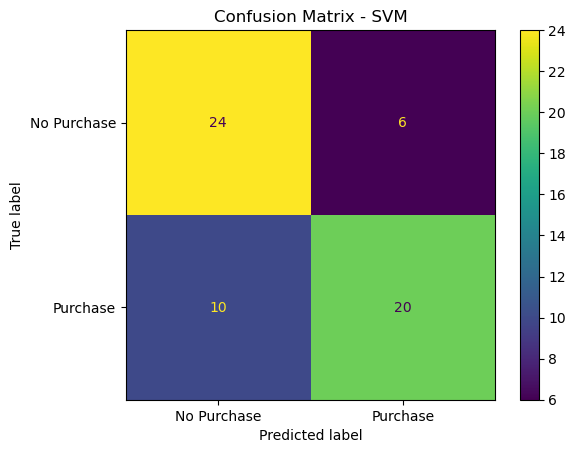

In [12]:
# 10. Build SVM Model

from sklearn.svm import SVC 
svm_model = SVC(random_state=42)
svm_model.fit(X_train_preprocessed, y_train)
print("SVM model trained successfully!")

y_pred_svm = svm_model.predict(X_test_preprocessed) 
print("SVM predictions completed successfully!") 
print("First 10 SVM predictions:")
print(y_pred_svm[:10])

# 11. Compare Actual & Predicted Values 

svm_comparison_df = pd.DataFrame({ 
    "Actual": y_test.values,
    "SVM_Predicted": y_pred_svm
})

display(svm_comparison_df.head(10))

# 12. Print Classification Metrics 

accuracy_svm = accuracy_score(y_test, y_pred_svm) 
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm) 
f1_svm = f1_score(y_test, y_pred_svm) 
cm_svm = confusion_matrix(y_test, y_pred_svm)

print("SVM Evaluation Metrics:") 
print("Accuracy:", accuracy_svm)
print("Precision:", precision_svm)
print("Recall:", recall_svm) 
print("F1-score:", f1_svm) 
print("Confusion Matrix - SVM:") 
print(cm_svm)

# 13. Create Display Object for Confusion Matrix 

display_cm_svm = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=["No Purchase", "Purchase"] 
)
display_cm_svm.plot() 
plt.title("Confusion Matrix - SVM") 
plt.show() 